In [2]:
# ==============================================================================
# SECTION 1: PROJECT INFORMATION & ENVIRONMENT VERIFICATION
# ==============================================================================
"""
Project : Skin Disease Classification using Transfer Learning
Framework : PyTorch
Model : MobileNetV2 (Pretrained)
Dataset : Final Processed Skin Disease Dataset
Classes : 9
Author : Varakavi Naga Manohar Raju

Objective:
Train a MobileNetV2 transfer learning model to classify
9 different skin conditions using a balanced dataset.
"""

print("=" * 70)
print("🚀 SKIN DISEASE CLASSIFICATION USING TRANSFER LEARNING")
print("=" * 70)

# ==============================================================================
# Import Required Libraries
# ==============================================================================

import os
import random
import platform
import numpy as np
import torch
import torchvision

# ==============================================================================
# Environment Information
# ==============================================================================

print("\n📌 Environment Information")
print("-" * 40)

print(f"Operating System : {platform.platform()}")
print(f"Python Version   : {platform.python_version()}")
print(f"PyTorch Version  : {torch.__version__}")
print(f"TorchVision      : {torchvision.__version__}")

# ==============================================================================
# GPU Verification
# ==============================================================================

print("\n📌 GPU Verification")
print("-" * 40)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"CUDA Available   : {torch.cuda.is_available()}")
print(f"Device           : {device}")

if torch.cuda.is_available():
    print(f"GPU Name         : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version     : {torch.version.cuda}")
    print(f"GPU Count        : {torch.cuda.device_count()}")

# ==============================================================================
# Reproducibility
# ==============================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("\n✅ Random Seed Set :", SEED)

print("\n" + "=" * 70)
print("✅ Environment Verification Completed Successfully")
print("=" * 70)

🚀 SKIN DISEASE CLASSIFICATION USING TRANSFER LEARNING

📌 Environment Information
----------------------------------------
Operating System : Windows-10-10.0.26200-SP0
Python Version   : 3.10.8
PyTorch Version  : 2.11.0+cu128
TorchVision      : 0.26.0+cu128

📌 GPU Verification
----------------------------------------
CUDA Available   : True
Device           : cuda
GPU Name         : NVIDIA GeForce RTX 4060 Laptop GPU
CUDA Version     : 12.8
GPU Count        : 1

✅ Random Seed Set : 42

✅ Environment Verification Completed Successfully


In [3]:
# ==============================================================================
# SECTION 2: IMPORT LIBRARIES & PROJECT CONFIGURATION
# ==============================================================================

print("=" * 70)
print("📦 Importing Libraries & Setting Configuration")
print("=" * 70)

# ==============================================================================
# Standard Libraries
# ==============================================================================

from pathlib import Path

# ==============================================================================
# Visualization
# ==============================================================================

import matplotlib.pyplot as plt

# ==============================================================================
# PyTorch
# ==============================================================================

import torch.nn as nn
import torch.optim as optim

# ==============================================================================
# TorchVision
# ==============================================================================

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# ==============================================================================
# Training Utilities
# ==============================================================================

from tqdm.auto import tqdm

# ==============================================================================
# Project Configuration
# ==============================================================================

PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "datasets" / "final_split_dataset"

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR   = DATASET_DIR / "val"
TEST_DIR  = DATASET_DIR / "test"

MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# ==============================================================================
# Hyperparameters
# ==============================================================================

IMAGE_SIZE = 224
NUM_CLASSES = 9

BATCH_SIZE = 32
NUM_EPOCHS = 20

LEARNING_RATE = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n📁 Dataset Directory :", DATASET_DIR)
print("🖥️ Device            :", DEVICE)

print("\n⚙️ Hyperparameters")
print("-" * 40)
print(f"Image Size     : {IMAGE_SIZE}")
print(f"Batch Size     : {BATCH_SIZE}")
print(f"Epochs         : {NUM_EPOCHS}")
print(f"Learning Rate  : {LEARNING_RATE}")
print(f"Classes        : {NUM_CLASSES}")

print("\n✅ Configuration Completed")

📦 Importing Libraries & Setting Configuration

📁 Dataset Directory : C:\Users\vnman\Desktop\virtual-internship\datasets\final_split_dataset
🖥️ Device            : cuda

⚙️ Hyperparameters
----------------------------------------
Image Size     : 224
Batch Size     : 32
Epochs         : 20
Learning Rate  : 0.001
Classes        : 9

✅ Configuration Completed


C:\Users\vnman\Desktop\virtual-internship\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ==============================================================================
# SECTION 3: DATA AUGMENTATION & DATALOADER
# ==============================================================================

print("=" * 70)
print("🖼️ Preparing Datasets & DataLoaders")
print("=" * 70)

# ==============================================================================
# Data Transformations
# ==============================================================================

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ==============================================================================
# Load Datasets
# ==============================================================================

train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=val_test_transforms
)

# ==============================================================================
# Create DataLoaders
# ==============================================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ==============================================================================
# Dataset Information
# ==============================================================================

print("\n📊 Dataset Statistics")
print("-" * 40)

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(val_dataset)}")
print(f"Testing Images    : {len(test_dataset)}")

print(f"\nNumber of Classes : {len(train_dataset.classes)}")

print("\nClass Names")
print("-" * 40)

for idx, class_name in enumerate(train_dataset.classes):
    print(f"{idx:2d} → {class_name}")

print("\n✅ DataLoaders Created Successfully")
print("=" * 70)

🖼️ Preparing Datasets & DataLoaders

📊 Dataset Statistics
----------------------------------------
Training Images   : 7560
Validation Images : 1308
Testing Images    : 1308

Number of Classes : 9

Class Names
----------------------------------------
 0 → Blackheads
 1 → Dark_Spots
 2 → Inflammatory_Acne
 3 → Normal
 4 → Pigmentation
 5 → Pores
 6 → Redness
 7 → Whiteheads
 8 → Wrinkles

✅ DataLoaders Created Successfully


🖼️ Visualizing Training Images


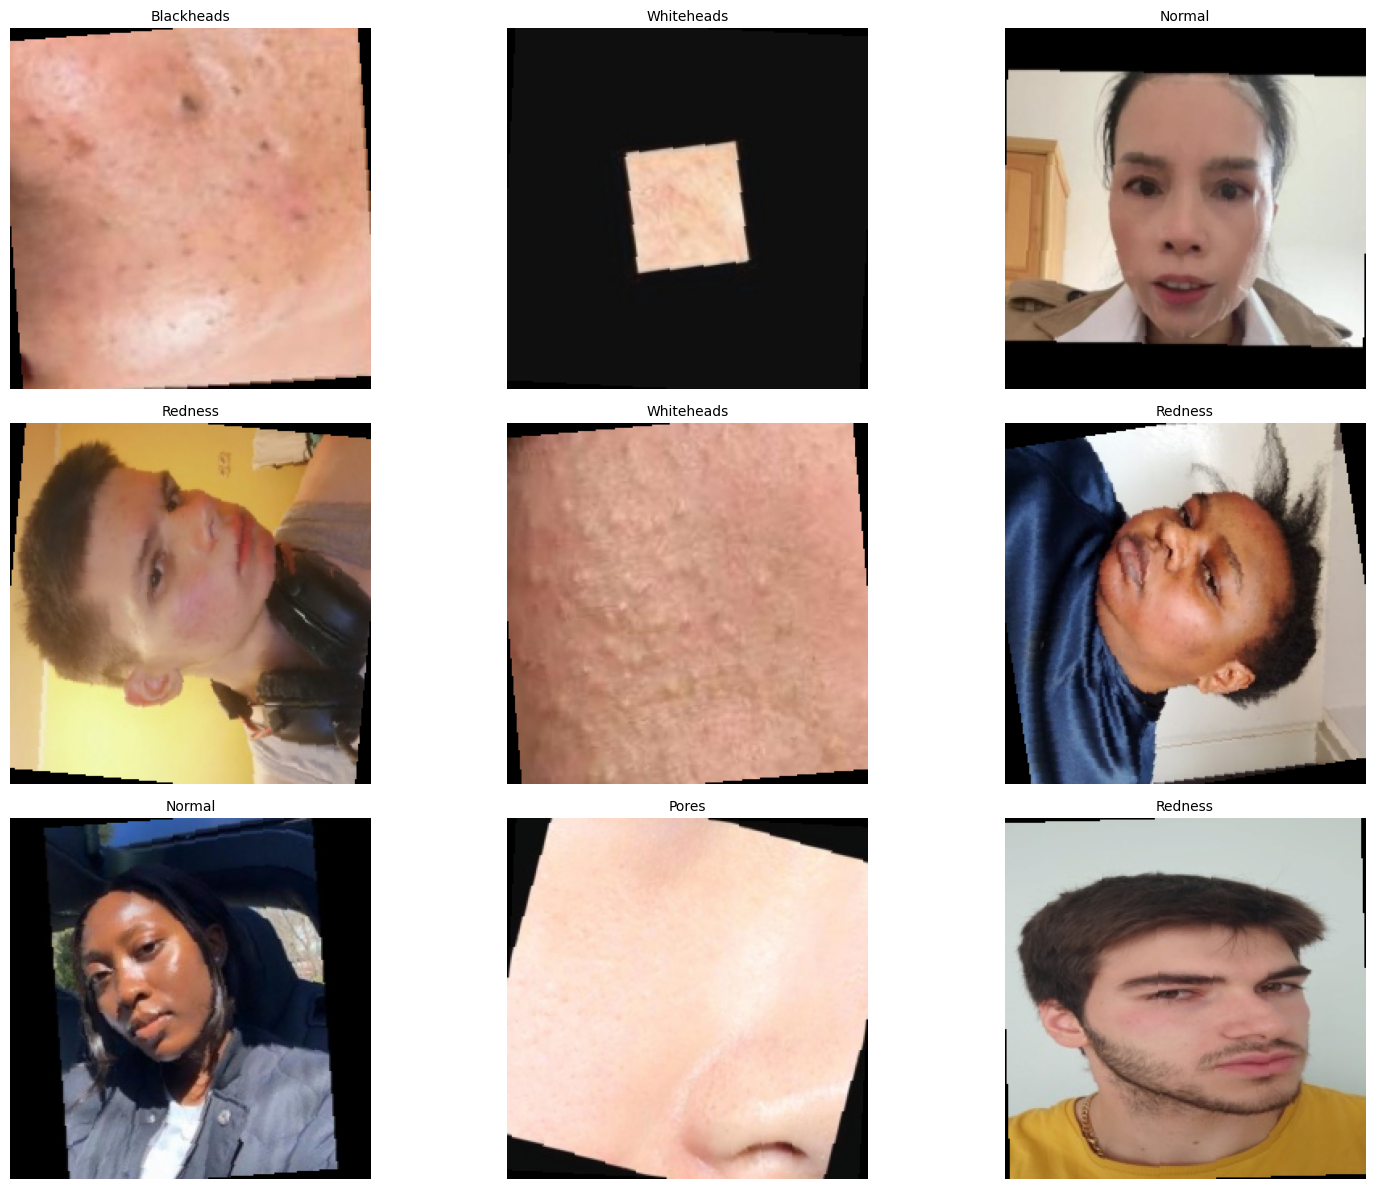


✅ Dataset Visualization Completed Successfully


In [5]:
# ==============================================================================
# SECTION 4: DATASET VISUALIZATION
# ==============================================================================

print("=" * 70)
print("🖼️ Visualizing Training Images")
print("=" * 70)

# ==============================================================================
# Helper Function
# ==============================================================================

def imshow(image, title=None):
    """
    Display a normalized PyTorch image.
    """

    image = image.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = std * image + mean
    image = np.clip(image, 0, 1)

    plt.imshow(image)

    if title is not None:
        plt.title(title, fontsize=10)

    plt.axis("off")


# ==============================================================================
# Load One Batch
# ==============================================================================

images, labels = next(iter(train_loader))

# ==============================================================================
# Display Images
# ==============================================================================

plt.figure(figsize=(16, 12))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    class_name = train_dataset.classes[labels[i]]

    imshow(images[i], class_name)

plt.tight_layout()
plt.show()

print("\n✅ Dataset Visualization Completed Successfully")

In [6]:
# ==============================================================================
# SECTION 5: LOAD PRETRAINED MOBILENETV2
# ==============================================================================

print("=" * 70)
print("🧠 Loading Pretrained MobileNetV2")
print("=" * 70)

from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

# ==============================================================================
# Load Pretrained Model
# ==============================================================================

weights = MobileNet_V2_Weights.DEFAULT

model = mobilenet_v2(weights=weights)

print("✅ Pretrained MobileNetV2 Loaded")

# ==============================================================================
# Freeze Feature Extractor
# ==============================================================================

for param in model.features.parameters():
    param.requires_grad = False

print("✅ Feature Extractor Frozen")

# ==============================================================================
# Replace Classification Head
# ==============================================================================

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features=in_features,
    out_features=NUM_CLASSES
)

print(f"✅ Classifier Replaced ({NUM_CLASSES} Classes)")

# ==============================================================================
# Move Model to GPU
# ==============================================================================

model = model.to(DEVICE)

print(f"✅ Model moved to {DEVICE}")

print("\n" + "=" * 70)
print("✅ MobileNetV2 Ready for Training")
print("=" * 70)

🧠 Loading Pretrained MobileNetV2
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\vnman/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:04<00:00, 3.03MB/s]


✅ Pretrained MobileNetV2 Loaded
✅ Feature Extractor Frozen
✅ Classifier Replaced (9 Classes)
✅ Model moved to cuda

✅ MobileNetV2 Ready for Training


In [7]:
# ==============================================================================
# SECTION 6: MODEL SUMMARY
# ==============================================================================

print("=" * 70)
print("📋 MobileNetV2 Model Summary")
print("=" * 70)

# ==============================================================================
# Count Parameters
# ==============================================================================

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

frozen_params = total_params - trainable_params

# ==============================================================================
# Display Information
# ==============================================================================

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")
print(f"Frozen Parameters     : {frozen_params:,}")

print("\nFinal Classification Layer")
print("-" * 40)

print(model.classifier)

print("\n" + "=" * 70)
print("✅ Model Summary Generated Successfully")
print("=" * 70)

📋 MobileNetV2 Model Summary
Total Parameters      : 2,235,401
Trainable Parameters  : 11,529
Frozen Parameters     : 2,223,872

Final Classification Layer
----------------------------------------
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=9, bias=True)
)

✅ Model Summary Generated Successfully


In [8]:
# ==============================================================================
# SECTION 7: LOSS FUNCTION, OPTIMIZER & LEARNING RATE SCHEDULER
# ==============================================================================

print("=" * 70)
print("⚙️ Configuring Training Components")
print("=" * 70)

# ==============================================================================
# Loss Function
# ==============================================================================

criterion = nn.CrossEntropyLoss()

# ==============================================================================
# Optimizer
# ==============================================================================

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

# ==============================================================================
# Learning Rate Scheduler
# ==============================================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print(f"Loss Function        : {criterion.__class__.__name__}")
print(f"Optimizer            : {optimizer.__class__.__name__}")
print(f"Initial Learning Rate: {LEARNING_RATE}")
print("Learning Rate Scheduler: ReduceLROnPlateau")

print("\n" + "=" * 70)
print("✅ Training Components Ready")
print("=" * 70)

⚙️ Configuring Training Components
Loss Function        : CrossEntropyLoss
Optimizer            : AdamW
Initial Learning Rate: 0.001
Learning Rate Scheduler: ReduceLROnPlateau

✅ Training Components Ready


In [9]:
# ==============================================================================
# SECTION 8: TRAINING & VALIDATION FUNCTIONS
# ==============================================================================

print("=" * 70)
print("🏋️ Defining Training & Validation Functions")
print("=" * 70)


# ==============================================================================
# Training Function
# ==============================================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predictions == labels).sum().item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy


# ==============================================================================
# Validation Function
# ==============================================================================

def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predictions = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy


print("\n✅ Training Function Created")
print("✅ Validation Function Created")

print("\n" + "=" * 70)
print("✅ Section Completed Successfully")
print("=" * 70)

🏋️ Defining Training & Validation Functions

✅ Training Function Created
✅ Validation Function Created

✅ Section Completed Successfully


In [10]:
# ==============================================================================
# SECTION 9: MAIN TRAINING LOOP
# ==============================================================================

print("=" * 70)
print("🚀 Starting Model Training")
print("=" * 70)

# ==============================================================================
# Variables
# ==============================================================================

best_val_loss = float("inf")
early_stop_counter = 0
EARLY_STOPPING_PATIENCE = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

# ==============================================================================
# Training Loop
# ==============================================================================

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")
    print("-" * 70)

    # -------------------------
    # Training
    # -------------------------

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    # -------------------------
    # Validation
    # -------------------------

    val_loss, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    # -------------------------
    # Scheduler Step
    # -------------------------

    scheduler.step(val_loss)

    # -------------------------
    # Save History
    # -------------------------

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # -------------------------
    # Print Metrics
    # -------------------------

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Learning Rate : {current_lr:.6f}")

    # -------------------------
    # Save Best Model
    # -------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        early_stop_counter = 0

        torch.save(
            model.state_dict(),
            MODEL_DIR / "mobilenetv2_best.pth"
        )

        print("✅ Best model saved.")

    else:

        early_stop_counter += 1
        print(f"No improvement ({early_stop_counter}/{EARLY_STOPPING_PATIENCE})")

    # -------------------------
    # Early Stopping
    # -------------------------

    if early_stop_counter >= EARLY_STOPPING_PATIENCE:

        print("\n🛑 Early stopping triggered.")
        break

print("\n" + "=" * 70)
print("🎉 Training Completed")
print("=" * 70)

print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Best Model Saved At : {MODEL_DIR / 'mobilenetv2_best.pth'}")

🚀 Starting Model Training

Epoch [1/20]
----------------------------------------------------------------------


Train Loss : 1.0310
Train Acc  : 67.35%
Val Loss   : 0.7208
Val Acc    : 71.25%
Learning Rate : 0.001000
✅ Best model saved.

Epoch [2/20]
----------------------------------------------------------------------


Train Loss : 0.6371
Train Acc  : 75.37%
Val Loss   : 0.6463
Val Acc    : 72.17%
Learning Rate : 0.001000
✅ Best model saved.

Epoch [3/20]
----------------------------------------------------------------------


Train Loss : 0.5663
Train Acc  : 76.76%
Val Loss   : 0.5877
Val Acc    : 74.39%
Learning Rate : 0.001000
✅ Best model saved.

Epoch [4/20]
----------------------------------------------------------------------


Train Loss : 0.5266
Train Acc  : 78.25%
Val Loss   : 0.5515
Val Acc    : 76.15%
Learning Rate : 0.001000
✅ Best model saved.

Epoch [5/20]
----------------------------------------------------------------------


...

Train Loss : 0.4046
Train Acc  : 80.81%
Val Loss   : 0.4365
Val Acc    : 78.98%
Learning Rate : 0.001000
✅ Best model saved.

Epoch [17/20]
----------------------------------------------------------------------


Train Loss : 0.4013
Train Acc  : 80.62%
Val Loss   : 0.4355
Val Acc    : 79.05%
Learning Rate : 0.001000
✅ Best model saved.

Epoch [18/20]
----------------------------------------------------------------------


Train Loss : 0.4043
Train Acc  : 80.62%
Val Loss   : 0.4482
Val Acc    : 78.59%
Learning Rate : 0.001000
No improvement (1/5)

Epoch [19/20]
----------------------------------------------------------------------


Train Loss : 0.3908
Train Acc  : 81.03%
Val Loss   : 0.4423
Val Acc    : 78.82%
Learning Rate : 0.001000
No improvement (2/5)

Epoch [20/20]
----------------------------------------------------------------------


Train Loss : 0.3909
Train Acc  : 80.82%
Val Loss   : 0.4444
Val Acc    : 78.59%
Learning Rate : 0.001000
No improvement (3/5)

🎉 Training Completed
Best Validation Loss: 0.4355
Best Model Saved At : C:\Users\vnman\Desktop\virtual-internship\models\mobilenetv2_best.pth


In [11]:
# ==============================================================================
# SECTION 10: LOAD BEST MODEL & TEST EVALUATION
# ==============================================================================

print("=" * 70)
print("🧪 Evaluating Best Model on Test Dataset")
print("=" * 70)

# ==============================================================================
# Load Best Model
# ==============================================================================

model.load_state_dict(
    torch.load(
        MODEL_DIR / "mobilenetv2_best.pth",
        map_location=DEVICE
    )
)

model.eval()

print("✅ Best Model Loaded Successfully")

# ==============================================================================
# Test Evaluation
# ==============================================================================

test_loss = 0.0
correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in tqdm(test_loader, desc="Testing"):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ==============================================================================
# Final Metrics
# ==============================================================================

test_loss /= total
test_accuracy = 100 * correct / total

print("\n" + "=" * 70)
print("📊 Test Results")
print("=" * 70)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.2f}%")

print("=" * 70)
print("✅ Test Evaluation Completed")
print("=" * 70)

🧪 Evaluating Best Model on Test Dataset
✅ Best Model Loaded Successfully


Testing: 100%|██████████| 41/41 [00:25<00:00,  1.62it/s]



📊 Test Results
Test Loss     : 0.4279
Test Accuracy : 77.29%
✅ Test Evaluation Completed


📈 Plotting Training History


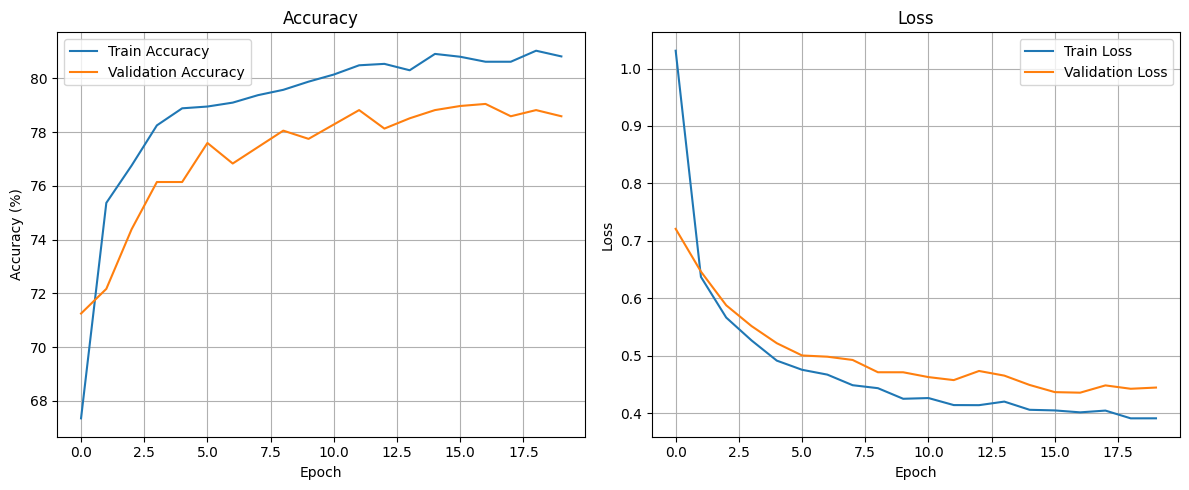

✅ Training Curves Generated


In [12]:
# ==============================================================================
# SECTION 11: TRAINING HISTORY VISUALIZATION
# ==============================================================================

print("=" * 70)
print("📈 Plotting Training History")
print("=" * 70)

plt.figure(figsize=(12,5))

# ------------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------------

plt.subplot(1,2,1)

plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

# ------------------------------------------------------------------
# Loss
# ------------------------------------------------------------------

plt.subplot(1,2,2)

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("✅ Training Curves Generated")

In [13]:
# ==============================================================================
# SECTION 12: CLASSIFICATION REPORT
# ==============================================================================

from sklearn.metrics import classification_report

print("=" * 70)
print("📋 Classification Report")
print("=" * 70)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes,
        digits=4
    )
)

📋 Classification Report
                   precision    recall  f1-score   support

       Blackheads     0.8867    0.7389    0.8061       180
       Dark_Spots     0.4911    0.3056    0.3767       180
Inflammatory_Acne     0.7989    0.8389    0.8184       180
           Normal     0.9389    0.9389    0.9389       180
     Pigmentation     0.4659    0.6444    0.5408       180
            Pores     0.9519    0.9889    0.9700       180
          Redness     0.8000    1.0000    0.8889         4
       Whiteheads     0.6949    0.9318    0.7961        44
         Wrinkles     0.9266    0.9111    0.9188       180

         accuracy                         0.7729      1308
        macro avg     0.7728    0.8109    0.7839      1308
     weighted avg     0.7772    0.7729    0.7684      1308



🔥 Confusion Matrix


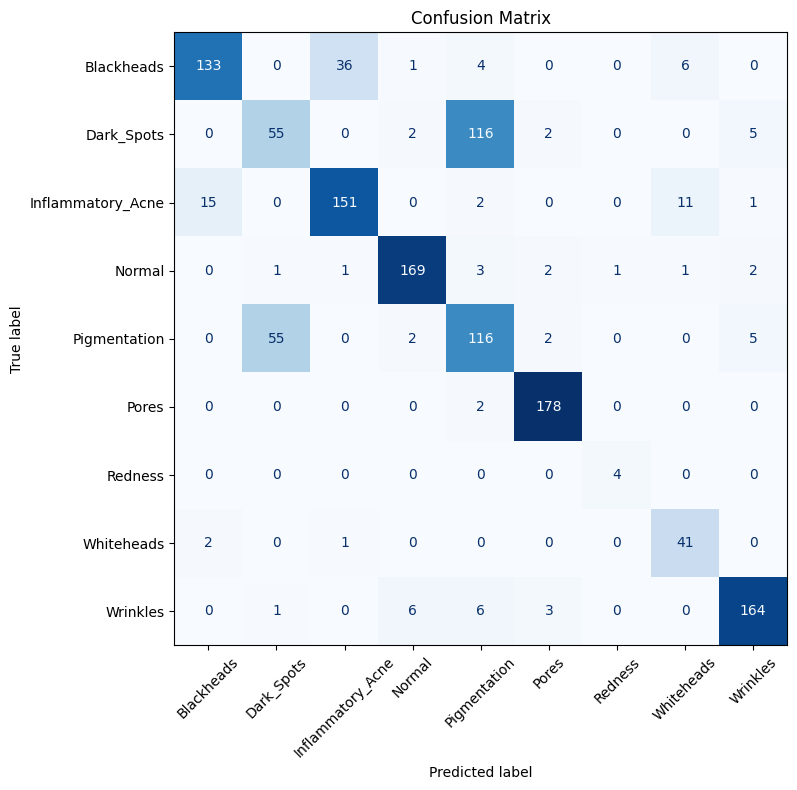


✅ Confusion Matrix Generated Successfully


In [14]:
# ==============================================================================
# SECTION 13: CONFUSION MATRIX
# ==============================================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("=" * 70)
print("🔥 Confusion Matrix")
print("=" * 70)

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=45,
    colorbar=False,
    values_format="d"
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print("\n✅ Confusion Matrix Generated Successfully")

🖼️ Sample Predictions


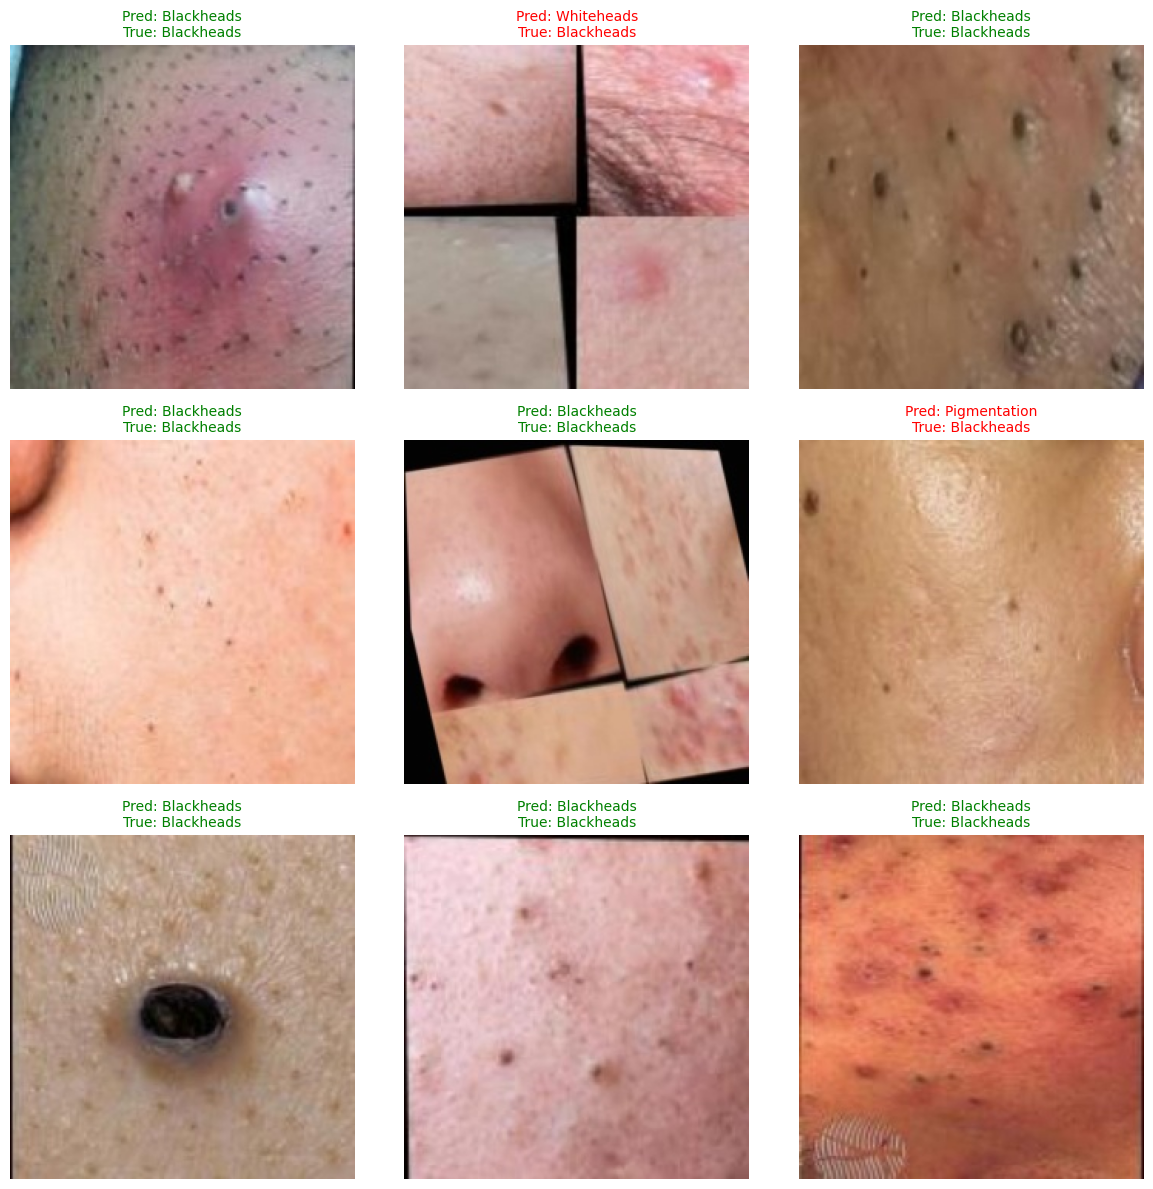


✅ Sample Predictions Generated Successfully


In [15]:
# ==============================================================================
# SECTION 14: SAMPLE PREDICTIONS
# ==============================================================================

print("=" * 70)
print("🖼️ Sample Predictions")
print("=" * 70)

model.eval()

# Get one batch
images, labels = next(iter(test_loader))

images_gpu = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images_gpu)
    _, predictions = torch.max(outputs, 1)

predictions = predictions.cpu()

# ImageNet normalization values
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(3,3, figsize=(12,12))

for i, ax in enumerate(axes.flat):

    image = images[i] * std + mean
    image = torch.clamp(image,0,1)

    image = image.permute(1,2,0)

    true_label = test_dataset.classes[labels[i]]
    pred_label = test_dataset.classes[predictions[i]]

    color = "green" if true_label == pred_label else "red"

    ax.imshow(image)
    ax.set_title(
        f"Pred: {pred_label}\nTrue: {true_label}",
        color=color,
        fontsize=10
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

print("\n✅ Sample Predictions Generated Successfully")